[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/florpi/rl-from-scratch/blob/solutions/rl_tutorial.ipynb)

In [1]:
!pip install -q "gymnasium[box2d]" torch matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 27.3 MB/s eta 0:00:00


In [2]:
import math
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

# Reproducibility (best-effort — gym envs use their own RNG that we seed at reset)
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Meet LunarLander

`LunarLander-v3` simulates a small lander descending toward a landing pad between two flags. The agent picks one of 4 discrete actions every step (do nothing, fire left engine, fire main engine, fire right engine) and gets a shaped reward:

- **Positive** reward for moving toward the pad, slowing down, and landing with both legs touching.
- **Negative** reward for crashing, drifting away, or firing engines (fuel is not free).
- **+100 / −100** terminal bonus for a successful landing / crash.

A return above ~200 is considered solved. A random policy gets around −200 (crashes fast, gets penalized).

- **State**: 8-D continuous — `(x, y, vx, vy, angle, angular_velocity, left_leg_contact, right_leg_contact)`
- **Actions**: 4 discrete
- **Episode length**: up to 1000 steps

This is the kind of problem RL really shines on: there's no obvious greedy strategy, you have to learn a feedback policy that handles unstable dynamics.

In [3]:
env = gym.make("LunarLander-v3")
obs, info = env.reset(seed=SEED)
print(f"Observation space: {env.observation_space}")

print(f"Action space:      {env.action_space}")

print(f"Sample observation: {obs}")

STATE_DIM = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n
print(f"State dim: {STATE_DIM}, n actions: {N_ACTIONS}")
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space:      Discrete(4)
Sample observation: [ 0.00570612  1.3990337   0.5779653  -0.5282997  -0.0066053  -0.13091765
  0.          0.        ]
State dim: 8, n actions: 4


In [4]:
# let's add a helper function to plot the returns

def plot_returns(returns, title, window=20):
    """Plot raw episode returns plus a rolling mean."""
    returns = np.asarray(returns)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(returns, alpha=0.3, label="episode return")
    if len(returns) >= window:
        rolling = np.convolve(returns, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(returns)), rolling,
                color="C1", linewidth=2, label=f"{window}-ep moving avg")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

In [5]:
import matplotlib.animation as animation
from IPython.display import HTML

env = gym.make("LunarLander-v3", render_mode="rgb_array")
state, _ = env.reset(seed=42)
frames, rewards = [], []
for _ in range(1000):
    frames.append(env.render())
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    rewards.append(reward)
    if terminated or truncated:
        frames.append(env.render())
        break
env.close()

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
im = ax.imshow(frames[0])
def update(i): im.set_array(frames[i]); return [im]
anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=30, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())



In [6]:
print(sum(rewards))

-340.4432418702107


## 1. REINFORCE — your turn

From the notes, the policy-gradient objective is

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [r(\tau)]$$

and after applying the log-derivative trick

$$\frac{\nabla_\theta \pi_\theta(\tau)}{\pi_\theta(\tau)} = \nabla_\theta \log \pi_\theta(\tau)$$

the gradient becomes

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \Big[ \nabla_\theta \log \pi_\theta(\tau) \cdot r(\tau) \Big]$$

estimated from sampled trajectories as

$$\nabla_\theta J(\theta) \approx \frac{1}{N} \sum_{i=1}^N r(\tau_i) \sum_t \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i)$$




### 1a. The policy network

A small MLP that maps state → logits over discrete actions. Implement the forward pass.


In [7]:
class PolicyNet(nn.Module):
    """Maps a state vector to logits over discrete actions.

    Architecture suggestion: two hidden layers of 128 units with tanh or relu.
    Output layer: linear (raw logits, no activation).
    """
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Args:
            state: shape (batch, state_dim) or (state_dim,)
        Returns:
            logits: shape (batch, n_actions) or (n_actions,)
        """
        return self.mlp(state)

## 1b. Sampling an action

Given a state, sample an action from the policy and also return the log-probability of that action. The log-prob is what we multiply by the return in the loss, so it has to be a tensor that's still attached to the autograd graph.

Hint: `torch.distributions.Categorical(logits=...)` gives you `.sample()` and `.log_prob(action)`.


In [8]:
def select_action(policy: PolicyNet, state: np.ndarray):
    """Sample an action from the policy and return (action, log_prob).

    Args:
        policy: the PolicyNet
        state: numpy array of shape (state_dim,)

    Returns:
        action: int — the sampled action
        log_prob: torch.Tensor scalar — log pi(a|s), with grad attached
    """
    # TODO:
    # 1. Convert state to a torch tensor (float32, on the right device).
    # 2. Forward through the policy to get logits.
    # 3. Build a Categorical distribution from the logits.
    # 4. Sample an action; get its log_prob.
    # 5. Return action.item() and the log_prob tensor.
    logits = policy(torch.as_tensor(state, dtype=torch.float32, device=device))
    categorical = torch.distributions.Categorical(logits=logits)
    action = categorical.sample()
    log_prob = categorical.log_prob(action)
    return action.item(), log_prob

### 1c. Computing the return

For vanilla REINFORCE, the "return of the trajectory" is just the sum of all rewards: $r(\tau) = \sum_{t=0}^{T} r_t$. Every timestep gets multiplied by this *same* scalar.


In [9]:
def compute_trajectory_return(rewards: list) -> float:
    """Sum the rewards of one episode.

    Args:
        rewards: Python list of floats, one per timestep.
    Returns:
        A single float: r(tau) = sum_t r_t.
    """
    return sum(rewards)


### 1d. The REINFORCE update

Given the log-probs and the trajectory return from one episode, compute the surrogate loss and take one optimizer step.

Recall: the gradient estimator is

$$\nabla_\theta J(\theta) \approx r(\tau) \sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)$$

so the surrogate loss (which when differentiated gives this gradient) is

$$\mathcal{L}(\theta) = -\, r(\tau) \sum_t \log \pi_\theta(a_t \mid s_t)$$

The negative sign is because we're minimizing.

In [10]:
def reinforce_update(optimizer, log_probs: list, trajectory_return: float):
    """Perform one REINFORCE policy update from one episode.

    Args:
        optimizer: torch.optim optimizer over the policy parameters.
        log_probs: list of scalar tensors, one per timestep, each with grad.
        trajectory_return: float, the total return of this trajectory.
    """
    # TODO:
    # 1. Stack the log_probs into a single tensor.
    # 2. Compute the loss: -(sum of log_probs) * trajectory_return.
    #    (Note: trajectory_return is a constant — no grad needed on it.)
    # 3. optimizer.zero_grad(); loss.backward(); optimizer.step().
    loss = -torch.stack(log_probs).sum() * trajectory_return
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

### 1e. Training loop (provided)

This loop is just bookkeeping — environment stepping, collecting log-probs and rewards, calling your functions. Read through it to see how the pieces connect, then run it.

> **Note on sample efficiency:** vanilla REINFORCE is *not* sample-efficient on LunarLander. With these default hyperparameters it'll show an upward trend over a few hundred episodes but won't fully solve the task — that's expected, and the whole point of sections 2 and 3. If you want to actually see it solve, leave it running for over 5000 episodes.


In [11]:
def train_reinforce(num_episodes=400, lr=5e-4, max_steps=1000, log_every=20):
    env = gym.make("LunarLander-v3")
    policy = PolicyNet(STATE_DIM, N_ACTIONS).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    episode_returns, losses = [], []
    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        log_probs, rewards = [], []
        for _ in range(max_steps):
            action, log_prob = select_action(policy, state)
            state, reward, terminated, truncated, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            if terminated or truncated:
                break

        traj_return = compute_trajectory_return(rewards)
        loss = reinforce_update(optimizer, log_probs, traj_return)
        episode_returns.append(sum(rewards))
        losses.append(loss)

        if (ep + 1) % log_every == 0:
            recent = np.mean(episode_returns[-log_every:])
            print(f"Episode {ep + 1:4d} | recent {log_every}-ep avg return: {recent:7.1f}")

    env.close()
    return policy, episode_returns, losses


In [12]:


# Run it (once you've filled in the TODOs above)
reinforce_policy, reinforce_returns, losses = train_reinforce(num_episodes=1_000)


Episode   20 | recent 20-ep avg return:  -193.3
Episode   40 | recent 20-ep avg return:  -185.4
Episode   60 | recent 20-ep avg return:  -166.3
Episode   80 | recent 20-ep avg return:  -168.1
Episode  100 | recent 20-ep avg return:  -155.2
Episode  120 | recent 20-ep avg return:  -194.2
Episode  140 | recent 20-ep avg return:  -158.9
Episode  160 | recent 20-ep avg return:  -156.9
Episode  180 | recent 20-ep avg return:  -176.5
Episode  200 | recent 20-ep avg return:  -180.0
Episode  220 | recent 20-ep avg return:  -166.2
Episode  240 | recent 20-ep avg return:  -118.3
Episode  260 | recent 20-ep avg return:  -151.3
Episode  280 | recent 20-ep avg return:  -171.9
Episode  300 | recent 20-ep avg return:  -153.9
Episode  320 | recent 20-ep avg return:  -151.5
Episode  340 | recent 20-ep avg return:  -169.0
Episode  360 | recent 20-ep avg return:  -144.4
Episode  380 | recent 20-ep avg return:  -158.9
Episode  400 | recent 20-ep avg return:  -176.9
Episode  420 | recent 20-ep avg return: 

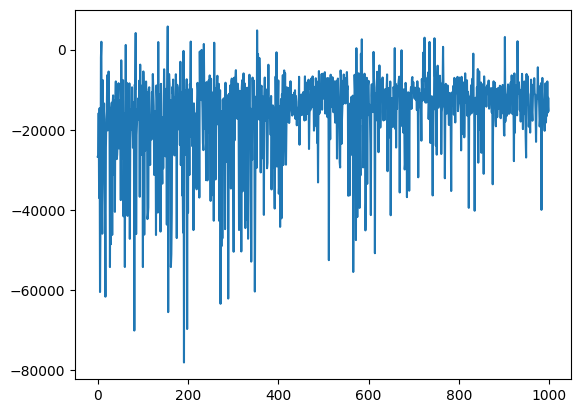

In [13]:
plt.plot(losses)

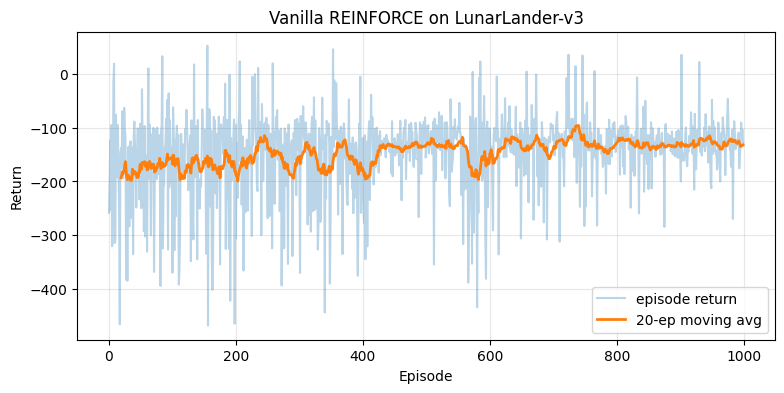

In [14]:
plot_returns(reinforce_returns, "Vanilla REINFORCE on LunarLander-v3")

In [15]:
import matplotlib.animation as animation
from IPython.display import HTML

env = gym.make("LunarLander-v3", render_mode="rgb_array")
state, _ = env.reset(seed=42)
frames, test_rewards = [], []
for _ in range(1000):
    frames.append(env.render())
    with torch.no_grad():
        action, log_prob = select_action(reinforce_policy, state)
    state, reward, terminated, truncated, _ = env.step(action)
    test_rewards.append(reward)
    if terminated or truncated:
        frames.append(env.render())
        break
env.close()

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
im = ax.imshow(frames[0])
def update(i): im.set_array(frames[i]); return [im]
anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=30, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

In [16]:
sum(test_rewards)

np.float64(-191.7701973932585)

## 2. Variance reduction: reward-to-go + baseline

Vanilla REINFORCE works in principle but suffers from **enormous variance**, because every action in a trajectory gets credited with the *same* total return — even actions taken long after the part of the episode they couldn't possibly have influenced. We'll address this in two steps from the notes.

### 2a. Reward-to-go + discounting

Instead of multiplying every $\log \pi(a_t \mid s_t)$ by the same $r(\tau)$, multiply it by the **return from time $t$ onward**:

$$G_t = \sum_{t' \geq t} \gamma^{t' - t}\, r_{t'}$$

This is *valid* because actions can't affect past rewards (so dropping them from the credit is unbiased), and *better* because every term has less noise. The discount factor $\gamma \in [0, 1)$ further reduces variance by down-weighting distant rewards — at the cost of a small bias (we're now optimizing a slightly different objective).

The gradient estimator becomes

$$\nabla_\theta J(\theta) \approx \mathbb{E}_\tau \Big[ \sum_t G_t \cdot \nabla_\theta \log \pi_\theta(a_t \mid s_t) \Big]$$


In [17]:
def compute_returns_to_go(rewards: list, gamma: float = 0.99) -> torch.Tensor:
    """Compute G_t = sum_{t' >= t} gamma^(t'-t) * r_{t'} for each t.

    Args:
        rewards: list of T floats.
        gamma: discount factor in [0, 1).
    Returns:
        Tensor of shape (T,) on `device`, where the t-th entry is G_t.

    Hint: compute this *backwards* in one pass:
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            ...prepend G to the list...
    """
    G_t = []
    G_accum = 0
    for r in reversed(rewards):
      G_accum = r + gamma * G_accum
      G_t.append(G_accum)
    G_t.reverse()
    return torch.tensor(G_t, dtype=torch.float32, device=device)


### 2b. Baseline → advantage

Subtracting a baseline $b$ from $G_t$ further reduces variance without introducing bias, as long as $b$ doesn't depend on the action:

$$\nabla_\theta J(\theta) \approx \mathbb{E}_\tau \Big[ \sum_t (G_t - b) \cdot \nabla_\theta \log \pi_\theta(a_t \mid s_t) \Big]$$

The simplest choice is the **mean return** across the batch. A more powerful choice (we'll get there in section 3) is a *state-dependent* baseline $V(s_t)$ — that's exactly what actor-critic does. For now, mean-subtraction with optional std-normalization works great.


In [18]:
def normalize_advantages(returns_to_go: torch.Tensor) -> torch.Tensor:
    """Subtract the mean

    This is the simplest "baseline": b = mean(G_t).


    Args:
        returns_to_go: tensor of shape (T,).
    Returns:
        tensor of shape (T,) with zero mean and unit-ish variance.
    """
    return returns_to_go - returns_to_go.mean()

### 2c. Improved REINFORCE update

Same idea as section 1d, but now each log-prob is multiplied by *its own* advantage instead of by the single trajectory return.

In [19]:
def reinforce_update_with_advantages(optimizer, log_probs: list,
                                       advantages: torch.Tensor):
    """REINFORCE update using per-timestep advantages.

    Args:
        optimizer: torch optimizer.
        log_probs: list of T scalar tensors with grad.
        advantages: tensor of shape (T,) — one advantage per timestep.

    The loss is: -(sum_t log_prob_t * advantage_t).
    """
    loss = - (torch.stack(log_probs) * advantages).sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [20]:
def train_reinforce_improved(num_episodes=400, lr=5e-4, gamma=0.99,
                              max_steps=1000, log_every=20):
    env = gym.make("LunarLander-v3")
    policy = PolicyNet(STATE_DIM, N_ACTIONS).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    episode_returns = []
    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        log_probs, rewards = [], []
        for _ in range(max_steps):
            action, log_prob = select_action(policy, state)
            state, reward, terminated, truncated, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            if terminated or truncated:
                break

        returns_to_go = compute_returns_to_go(rewards, gamma=gamma)
        advantages = normalize_advantages(returns_to_go)
        reinforce_update_with_advantages(optimizer, log_probs, advantages)
        episode_returns.append(sum(rewards))

        if (ep + 1) % log_every == 0:
            recent = np.mean(episode_returns[-log_every:])
            print(f"Episode {ep + 1:4d} | recent {log_every}-ep avg return: {recent:7.1f}")

    env.close()
    return policy, episode_returns


Episode   20 | recent 20-ep avg return:  -204.9
Episode   40 | recent 20-ep avg return:  -200.1
Episode   60 | recent 20-ep avg return:  -151.3
Episode   80 | recent 20-ep avg return:  -171.2
Episode  100 | recent 20-ep avg return:  -133.3
Episode  120 | recent 20-ep avg return:  -147.5
Episode  140 | recent 20-ep avg return:  -136.6
Episode  160 | recent 20-ep avg return:  -140.2
Episode  180 | recent 20-ep avg return:  -104.4
Episode  200 | recent 20-ep avg return:  -109.8
Episode  220 | recent 20-ep avg return:  -121.0
Episode  240 | recent 20-ep avg return:  -129.4
Episode  260 | recent 20-ep avg return:  -132.8
Episode  280 | recent 20-ep avg return:  -162.0
Episode  300 | recent 20-ep avg return:  -128.1
Episode  320 | recent 20-ep avg return:  -134.1
Episode  340 | recent 20-ep avg return:  -148.7
Episode  360 | recent 20-ep avg return:   -93.3
Episode  380 | recent 20-ep avg return:  -135.3
Episode  400 | recent 20-ep avg return:   -96.3
Episode  420 | recent 20-ep avg return: 

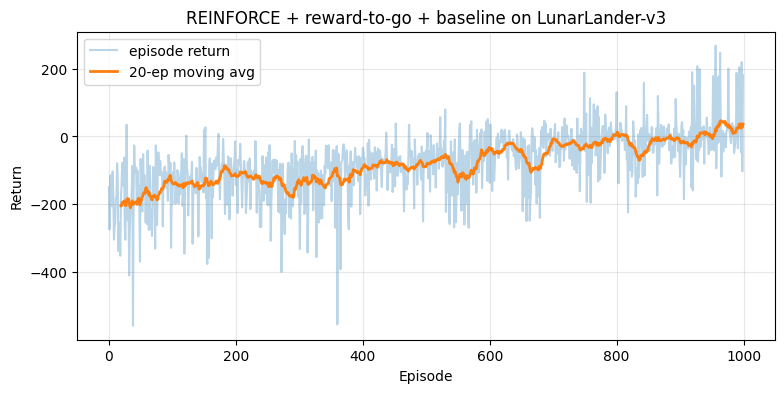

In [21]:


improved_policy, improved_returns = train_reinforce_improved(num_episodes=1_000)
plot_returns(improved_returns, "REINFORCE + reward-to-go + baseline on LunarLander-v3")


## 3. Actor-Critic

The natural next step: instead of using the empirical mean as our baseline, **learn** a value function $V_\phi^\pi(s)$ that predicts the expected return from state $s$ under the current policy. Then our advantage is

$$\hat{A}_t = G_t - V_\phi^\pi(s_t)$$

— a *state-dependent* baseline, much tighter than the batch mean (it subtracts off the part of the return that's "explained by where you started" rather than by your action). The critic is trained by regressing $V_\phi$ onto the actual returns:

$$\mathcal{L}_\text{critic}(\phi) = \mathbb{E}\big[ (V_\phi(s_t) - G_t)^2 \big]$$

We have **two networks** now: the actor $\pi_\theta$ (same as before) and the critic $V_\phi$. The total loss is their sum.""")

### 3a. The value network

Same MLP shape as the policy, but with a single scalar output.

In [22]:
class ValueNet(nn.Module):
    """Maps a state vector to a scalar value estimate V(s).

    Architecture suggestion: two hidden layers of 128 units, output is 1 scalar.
    """
    def __init__(self, state_dim: int, hidden: int = 128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Args:
            state: shape (batch, state_dim) or (state_dim,)
        Returns:
            value: shape (batch,) or scalar — V(s)

        """
        return self.mlp(state).squeeze(-1)

### 3b. Computing the advantage

Given the returns-to-go and the value predictions, the advantage at each timestep is just the difference. One subtlety: we want the advantage to act as a *constant* multiplier on the actor's log-probs — we don't want actor gradients to flow into the critic. We'll handle the `.detach()` in the loss function below; here, just compute the raw difference.


In [23]:
def compute_advantages(returns_to_go: torch.Tensor,
                       values: torch.Tensor) -> torch.Tensor:
    """Compute A_t = G_t - V(s_t).

    Args:
        returns_to_go: tensor (T,)
        values:        tensor (T,) — V(s_t) for each timestep, with grad
    Returns:
        tensor (T,) of advantages.
    """
    return returns_to_go - values

### 3c. The combined actor-critic update

One step, two losses:

- **Actor loss:** $-\sum_t \log \pi_\theta(a_t \mid s_t) \cdot \hat{A}_t^{\,\text{detached}}$
- **Critic loss:** $\frac{1}{T}\sum_t (V_\phi(s_t) - G_t)^2$
- **Total:** actor loss + (coefficient) × critic loss

You can either use one optimizer over both networks' parameters (simplest), or two optimizers (slightly more flexible). The provided training loop uses one.


In [24]:
def actor_critic_update(optimizer, log_probs: list,
                        values: torch.Tensor,
                        returns_to_go: torch.Tensor,
                        value_loss_coef: float = 0.5):
    """One combined actor-critic update from one episode.

    Args:
        optimizer: optimizer over actor.parameters() + critic.parameters()
        log_probs: list of T scalar tensors with grad (from the actor)
        values:    tensor (T,) of V(s_t), with grad (from the critic)
        returns_to_go: tensor (T,) — empirical returns, no grad
        value_loss_coef: weight on the critic loss

    Loss = actor_loss + value_loss_coef * critic_loss
        actor_loss  = -(sum_t log_prob_t * advantage_t.detach())
        critic_loss = MSE(values, returns_to_go)
    """
    # TODO:
    # 1. Compute advantages = returns_to_go - values  (use compute_advantages).
    # 2. Compute actor_loss using log_probs and advantages.
    # 3. Compute critic_loss = F.mse_loss(values, returns_to_go).
    # 4. loss = actor_loss + value_loss_coef * critic_loss.
    # 5. zero_grad, backward, step.
    advantage = compute_advantages(returns_to_go, values)
    actor_loss = -(torch.stack(log_probs) * advantage.detach()).sum()
    critic_loss = F.mse_loss(values, returns_to_go)
    loss = actor_loss + value_loss_coef * critic_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

### 3d. Training loop (provided)

Note that we now collect the **states** as well as the log-probs and rewards — we need them to compute $V_\phi(s_t)$ at the end of the episode.


In [25]:
def train_actor_critic(num_episodes=400, lr=5e-4, gamma=0.99,
                       max_steps=1000, log_every=20, value_loss_coef=0.5):
    env = gym.make("LunarLander-v3")
    actor = PolicyNet(STATE_DIM, N_ACTIONS).to(device)
    critic = ValueNet(STATE_DIM).to(device)
    optimizer = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)

    episode_returns = []
    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        log_probs, rewards, states = [], [], []
        for _ in range(max_steps):
            states.append(state)
            action, log_prob = select_action(actor, state)
            state, reward, terminated, truncated, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            if terminated or truncated:
                break

        # Critic predictions over the visited states (need grad here)
        states_t = torch.as_tensor(np.array(states), dtype=torch.float32, device=device)
        values = critic(states_t)  # shape (T,)
        returns_to_go = compute_returns_to_go(rewards, gamma=gamma)

        actor_critic_update(optimizer, log_probs, values, returns_to_go,
                            value_loss_coef=value_loss_coef)
        episode_returns.append(sum(rewards))

        if (ep + 1) % log_every == 0:
            recent = np.mean(episode_returns[-log_every:])
            print(f"Episode {ep + 1:4d} | recent {log_every}-ep avg return: {recent:7.1f}")

    env.close()
    return actor, critic, episode_returns




Episode   20 | recent 20-ep avg return:  -163.9
Episode   40 | recent 20-ep avg return:  -203.3
Episode   60 | recent 20-ep avg return:  -192.6
Episode   80 | recent 20-ep avg return:  -174.7
Episode  100 | recent 20-ep avg return:  -169.0
Episode  120 | recent 20-ep avg return:  -153.6
Episode  140 | recent 20-ep avg return:  -170.4
Episode  160 | recent 20-ep avg return:  -190.4
Episode  180 | recent 20-ep avg return:  -166.7
Episode  200 | recent 20-ep avg return:  -164.0
Episode  220 | recent 20-ep avg return:  -170.4
Episode  240 | recent 20-ep avg return:  -126.5
Episode  260 | recent 20-ep avg return:  -115.2
Episode  280 | recent 20-ep avg return:  -150.5
Episode  300 | recent 20-ep avg return:  -148.6
Episode  320 | recent 20-ep avg return:  -129.5
Episode  340 | recent 20-ep avg return:  -147.5
Episode  360 | recent 20-ep avg return:  -116.4
Episode  380 | recent 20-ep avg return:  -127.2
Episode  400 | recent 20-ep avg return:  -101.9
Episode  420 | recent 20-ep avg return: 

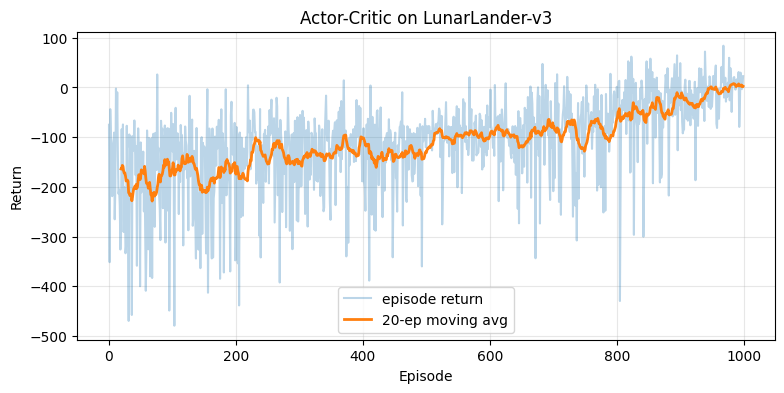

In [26]:
ac_actor, ac_critic, ac_returns = train_actor_critic(num_episodes=1_000)
plot_returns(ac_returns, "Actor-Critic on LunarLander-v3")

Stack all three curves together to see the progression.


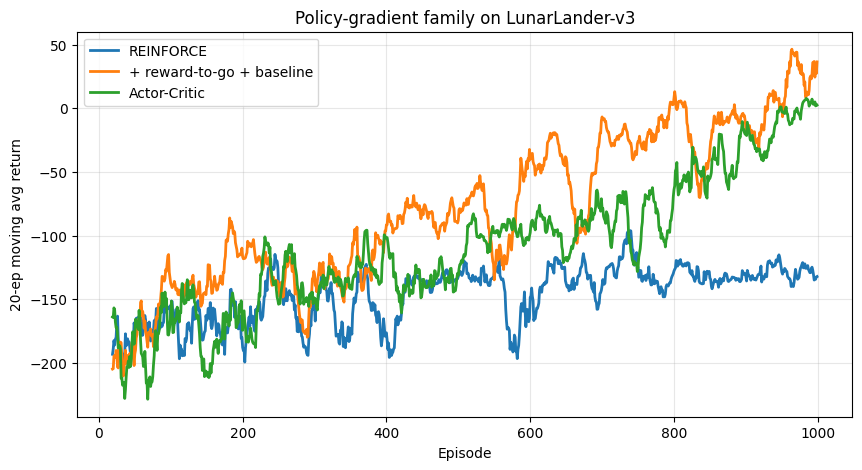

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
window = 20
for label, returns, color in [
    ("REINFORCE",                 reinforce_returns, "C0"),
    ("+ reward-to-go + baseline", improved_returns,  "C1"),
    ("Actor-Critic",              ac_returns,        "C2"),
]:
    arr = np.asarray(returns)
    if len(arr) >= window:
        rolling = np.convolve(arr, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(arr)), rolling, color=color,
                linewidth=2, label=label)
ax.set_xlabel("Episode")
ax.set_ylabel(f"{window}-ep moving avg return")
ax.set_title("Policy-gradient family on LunarLander-v3")
ax.legend()
ax.grid(alpha=0.3)
plt.show()